In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/anirudhchauhan/retail-store-inventory-forecasting-dataset/retail_store_inventory.csv


In [2]:
df=pd.read_csv("/kaggle/input/datasets/anirudhchauhan/retail-store-inventory-forecasting-dataset/retail_store_inventory.csv")
df.head(5)

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


In [3]:
df.dtypes

Date                   object
Store ID               object
Product ID             object
Category               object
Region                 object
Inventory Level         int64
Units Sold              int64
Units Ordered           int64
Demand Forecast       float64
Price                 float64
Discount                int64
Weather Condition      object
Holiday/Promotion       int64
Competitor Pricing    float64
Seasonality            object
dtype: object

# Data Cleaning Pipeline

In [4]:
import pandas as pd

def cleaned_data(df):
    
    # 1. Normalize column names first
    df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

    # 2. Handle date consistencies
    df['date'] = pd.to_datetime(df['date'], errors='coerce',format='mixed') 

    # 3. Drop rows where date cannot be parsed
    df = df.dropna(subset=['date'])

    # 4. Sort by date
    df = df.sort_values(by='date')

    # 5. Drop duplicate rows
    df = df.drop_duplicates()

    # 6. Set multi-index (date, product_id, store_id)
    df = df.set_index(['date', 'product_id', 'store_id'])

    # 7. Handle missing values
    for col in df.select_dtypes(include=['float64','int64']).columns:
        df[col] = df[col].fillna(df[col].median())
    for col in df.select_dtypes(include=['object']).columns:
        df[col] = df[col].fillna("Unknown")

    return df


In [5]:
cleaned_data(df)

category region  inventory_level  \
date       product_id store_id                                        
2022-01-01 P0001      S001        Groceries  North              231   
           P0013      S004        Furniture   East              191   
           P0012      S004      Electronics  North              349   
           P0011      S004      Electronics   West              205   
           P0010      S004        Groceries   East              447   
...                                     ...    ...              ...   
2024-01-01 P0008      S002        Furniture  North              218   
           P0007      S002             Toys   West               53   
           P0006      S002             Toys   East              160   
           P0016      S002             Toys  North              258   
           P0020      S005        Groceries   East              117   

                                units_sold  units_ordered  demand_forecast  \
date       product_id store_id                                               
2022-01-01 P0001      S001             127             55           135.47   
           P0013      S004              56             65            54.47   
           P0012      S004               9            165             0.95   
           P0011      S004              46             27            46.65   
           P0010      S004             104             96           115.03   
...                                    ...            ...              ...   
2024-01-01 P0008      S002              43            144            51.52   
           P0007      S002               2             40            -6.08   
           P0006      S002             159             78           151.48   
           P0016      S002             110            197           107.61   
           P0020      S005               6            165             2.33   

                                price  discount weather_condition  \
date       product_id store_id                                      
2022-01-01 P0001      S001      33.50        20             Rainy   
           P0013      S004      61.81         0             Sunny   
           P0012      S004      14.25         5             Rainy   
           P0011      S004      54.84         0             Sunny   
           P0010      S004      33.48        15            Cloudy   
...                               ...       ...               ...   
2024-01-01 P0008      S002      90.38        10             Sunny   
           P0007      S002      63.66        20             Snowy   
           P0006      S002      19.06        20             Rainy   
           P0016      S002      41.30         5            Cloudy   
           P0020      S005      78.39        20             Rainy   

                                holiday/promotion  competitor_pricing  \
date       product_id store_id                                          
2022-01-01 P0001      S001                      0               29.69   
           P0013      S004                      0               63.92   
           P0012      S004                      1               18.56   
           P0011      S004                      1               57.76   
           P0010      S004                      0               37.15   
...                                           ...                 ...   
2024-01-01 P0008      S002                      0               94.87   
           P0007      S002                      1               62.37   
           P0006      S002                      1               15.59   
           P0016      S002                      0               44.96   
           P0020      S005                      1               79.52   

                               seasonality  
date       product_id store_id              
2022-01-01 P0001      S001          Autumn  
           P0013      S004          Autumn  
           P0012      S004          Spring  
           P0011      S

In [6]:
# Cleaning the categorical columns
import re

def categorical_clean(a):
    if pd.isnull(a):
        return a
    a = str(a) # ensuring the following is string datatype

    # keeping only the aplhanumeric,spaces,punctuations
    a= re.sub(r"[^a-zA-Z\s\.,-]","",a)
    # normalizing the Whitespace
    a= re.sub(r"\s+"," ",a).strip()

    return a

# Applying the above the to the categorical features
def categorical_clean2(df, text_cols):
    for i in text_cols:
        if i in df.columns:
            df[i]= df[i].apply(categorical_clean)
    return df        

In [7]:
text_cols=['region','category','seasonality','weather_condition']
df= categorical_clean2(df,text_cols)

In [8]:
df.dtypes

date                  datetime64[ns]
store_id                      object
product_id                    object
category                      object
region                        object
inventory_level                int64
units_sold                     int64
units_ordered                  int64
demand_forecast              float64
price                        float64
discount                       int64
weather_condition             object
holiday/promotion              int64
competitor_pricing           float64
seasonality                   object
dtype: object

In [9]:
df.info() # No null values is present

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   date                73100 non-null  datetime64[ns]
 1   store_id            73100 non-null  object        
 2   product_id          73100 non-null  object        
 3   category            73100 non-null  object        
 4   region              73100 non-null  object        
 5   inventory_level     73100 non-null  int64         
 6   units_sold          73100 non-null  int64         
 7   units_ordered       73100 non-null  int64         
 8   demand_forecast     73100 non-null  float64       
 9   price               73100 non-null  float64       
 10  discount            73100 non-null  int64         
 11  weather_condition   73100 non-null  object        
 12  holiday/promotion   73100 non-null  int64         
 13  competitor_pricing  73100 non-null  float64   

In [10]:
df.describe()

,date,inventory_level,units_sold,units_ordered,demand_forecast,price,discount,holiday/promotion,competitor_pricing
count,73100,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,2022-12-31 23:59:59.999999744,274.469877,136.464870,110.004473,141.494720,55.135108,10.009508,0.497305,55.146077
min,2022-01-01 00:00:00,50.000000,0.000000,20.000000,-9.990000,10.000000,0.000000,0.000000,5.030000
25%,2022-07-02 00:00:00,162.000000,49.000000,65.000000,53.670000,32.650000,5.000000,0.000000,32.680000
50%,2023-01-01 00:00:00,273.000000,107.000000,110.000000,113.015000,55.050000,10.000000,0.000000,55.010000
75%,2023-07-03 00:00:00,387.000000,203.000000,155.000000,208.052500,77.860000,15.000000,1.000000,77.820000
max,2024-01-01 00:00:00,500.000000,499.000000,200.000000,518.550000,100.000000,20.000000,1.000000,104.940000
std,NaN,129.949514,108.919406,52.277448,109.254076,26.021945,7.083746,0.499996,26.191408


# EDA

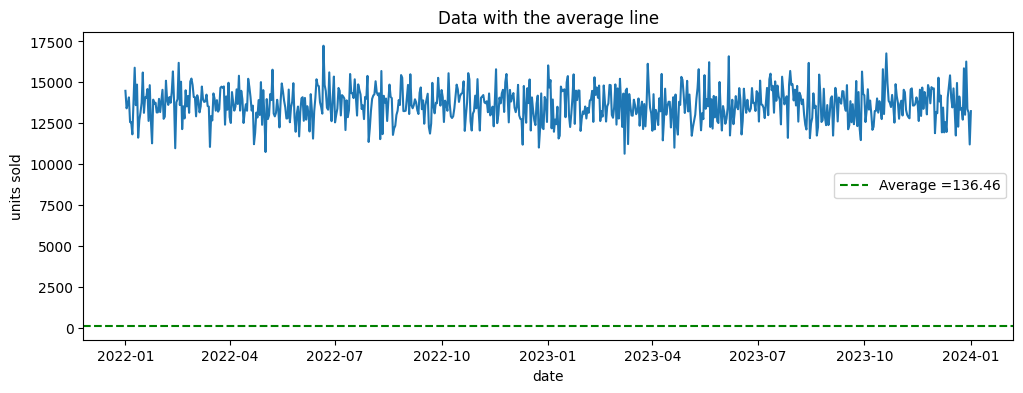

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

daily = df.groupby('date')['units_sold'].sum()
avg= np.mean(df['units_sold']) # Calculate the average line
plt.figure(figsize=(12,4))
plt.plot(daily)
plt.title("Data with the average line")

plt.axhline(y= avg,color='green', linestyle= '--', label= f'Average ={avg:.2f}')
plt.xlabel('date')
plt.ylabel('units sold')

plt.legend()
plt.show()

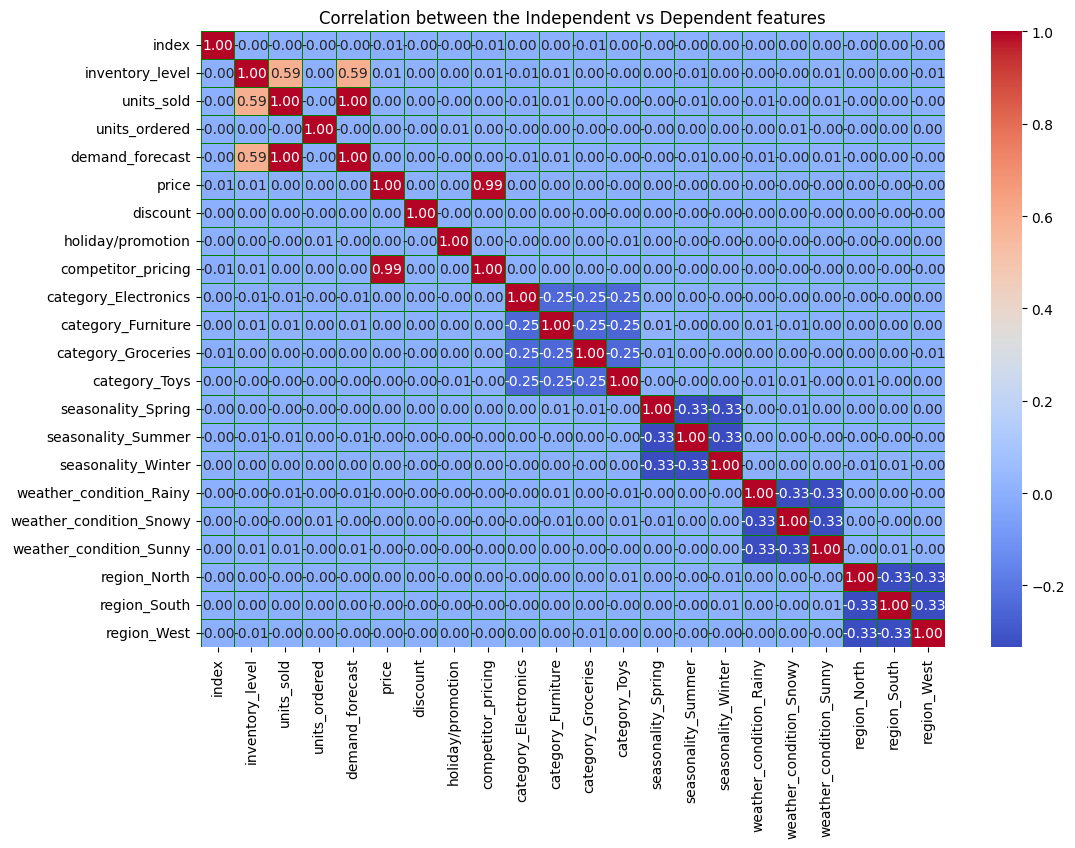

In [12]:
text_cols1=['category','seasonality','weather_condition','region']
df_encoded= pd.get_dummies(df,columns=text_cols1,drop_first=True,dtype=int)
df_encoded= df_encoded.reset_index() # Setting the indexes
df_encoded= df_encoded.drop(columns=['product_id','store_id','date']) # Dropping the unwanted columns


cor_df=df_encoded.corr()

plt.figure(figsize=(12,8))
sns.heatmap(cor_df,annot=True,cmap='coolwarm',fmt='.2f',linewidths=0.5,linecolor='green')
plt.title("Correlation between the Independent vs Dependent features")
plt.show()

# Model Building

In [13]:
df1= df.reset_index()
df1.drop(columns='index',inplace=True)

In [14]:
# Creating Lag and Rolling Features

df1= df1.sort_values(by=['store_id','product_id','date'])

# Create lag features for Sales
df1['sales_lag1']= df1.groupby(['store_id','product_id'])['units_sold'].shift(1)
df1['sales_lag7']= df1.groupby(['store_id','product_id'])['units_sold'].shift(7)

# 7 Day Rolling Mean and sum of sales
df1['sales_rolling_mean_7']= df1.groupby(['store_id','product_id'])['units_sold'].transform(
                                lambda x: x.rolling(7).mean())

df1['sales_rolling_sum_7']= df1.groupby(['store_id','product_id'])['units_sold'].transform(
                                lambda x: x.rolling(7).sum())


In [15]:
# Handling the missing values from Rolling
df1= df1.dropna(subset=['sales_lag1','sales_rolling_mean_7'])

In [16]:
df1=df1.drop(columns=['store_id','product_id']) # Dropping the insignificant columns

In [17]:
# Encoding the necessary columns
df1['category'].value_counts()

category
Furniture      14593
Clothing       14518
Toys           14502
Groceries      14486
Electronics    14401
Name: count, dtype: int64

In [18]:
df2= df1.copy()
df2= pd.get_dummies(df2,columns=['category','region','weather_condition','seasonality'],drop_first=True, dtype=int)

In [19]:
# Time Based Splitting of the data
df2['year']= df2['date'].dt.year
df2['month']= df2['date'].dt.month
df2['day']= df2['date'].dt.day


cutoff_date= df2['date'].quantile(0.8, interpolation='nearest')
train= df2[df2['date']< cutoff_date]
test= df2[df2['date']>= cutoff_date]

from sklearn.model_selection import TimeSeriesSplit
tscv= TimeSeriesSplit(n_splits=5) # Used Time series cross validation for the expanding or
                                  # rolling window
y= df2['units_sold'].values

# Naive forecast
naive_forecast= np.roll(y,1)

# Computing the baseline error
mae_naive= np.mean(np.abs(y[1:]- naive_forecast[1:]))
print("Naive Mae :",mae_naive)

Naive Mae : 120.02114511924303


In [20]:
features= df2.drop(columns=['date','units_sold']).columns.tolist()
target= df2['units_sold']

In [21]:
x_train= train.drop(columns=['date','units_sold'])
y_train= train['units_sold']


x_test= test.drop(columns=['date','units_sold'])
y_test= test['units_sold']
#Applying the Scaling features

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

In [22]:
scaler= StandardScaler()

# Fitting only on training data
x_train_scaled= scaler.fit_transform(x_train)

# Transform test data using the same color
x_test_scaled= scaler.transform(x_test)


# Linear Regression (Base Model)


In [23]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

pipeline= Pipeline(
    [
        ('imputer', SimpleImputer(strategy= 'mean')),
        ('model',LinearRegression())
    ]
)

pipeline.fit(x_train_scaled,y_train)

y_pred= pipeline.predict(x_test_scaled)
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
mae= mean_absolute_error(y_test,y_pred)
rmse= root_mean_squared_error(y_test,y_pred)
print("RMSE:\n",rmse)
print("MAE:\n",mae)

RMSE:
 8.692051341297436
MAE:
 7.519353182058272


# Inventory Optimization

In [29]:
df= df.sort_values(by=["date","store_id","product_id"])

df3= df.copy()

group_cols=['store_id','product_id']

df3['stockout_flag']= df3['units_sold'] >= df3['inventory_level']
df3['overstock_flag']= df3['inventory_level'] > df3['units_sold']*2

In [25]:
baseline_stockout_rate= df3['stockout_flag'].mean()
baseline_overstock_rate= df3['overstock_flag'].mean()
baseline_avg_excess_units= (df3['inventory_level']- df3['units_sold']).clip(lower=0).mean()

print(f"Baseline Stockout rate is {baseline_stockout_rate:.2%}")
print(f"Baseline Overstock rate is {baseline_overstock_rate:.2%}")
print(f"Baseline Average Excess Units/day is {baseline_avg_excess_units:.2f}")

Baseline Stockout rate is 0.50%
Baseline Overstock rate is 50.32%
Baseline Average Excess Units/day is 138.01


In [26]:
# Demand Variablity per Store product
from scipy.stats import norm


demand_stats=(
    df3.groupby(by=['date','store_id','product_id'])['units_sold']
    .agg(mean_demand='mean', std_demand='std',total_units='sum')
    .fillna(0)
)

service_level= 0.92 # How often are we okay not stocking out
lead_days= 3 # days between placing a order and receivable
z= norm.ppf(service_level)

# Safety Stock
demand_stats['safety_stock']= z* demand_stats['std_demand']* np.sqrt(lead_days)

# Reorder Point
# reorder point is the expected demand during the lead time + safety stock

demand_stats['reorder_point']= (
    demand_stats['mean_demand']* lead_days + demand_stats['safety_stock']
)


# Order-up-to-level (Simple periodic review policy)
# Covers a review period (e.g. weekly) plus safety cushion

review_period= 7
demand_stats['order_to_level']= (
    demand_stats['mean_demand']* review_period + demand_stats['safety_stock']
)

In [28]:
# BackTest Simulation: replay history using the new review policy
# and compare stockouts/overstock vs actual review policy

def simulate_policy(df,reorder_point,order_to_level,lead_days):
    n= len(df)
    demand= df['units_sold'].values
    sim_inventory= np.zeros(n)
    on_order= np.zeros(n) # units incoming,indexed by arrival of day
    stockouts= np.zeros(n,dtype=bool)
    inv= order_to_level
    pending_orders= dict()

    for i in range(n):
        # receive any orders arriving today
        if i in pending_orders:
            inv+= pending_orders.pop(i)
        # serves todays demand
        sold= min(inv,demand[i])
        stockout[i]= demand[i] > inv
        inv-= sold 

        # check reorder trigger
        if inv <= reorder_point:
            qty= max(order_to_level-inv,0)
            arrival= i+lead_days
            if arrival < n:
                pending_orders[arrival]= pending_orders.get(arrival,0)+ qty
        sim_inventory[i]= inv
     
    return sim_inventory,stockout   

In [ ]:
results = []
for (store_id, product_id), grp in df.groupby(group_cols):
    grp = grp.sort_values("date")
    params = demand_stats[
        (demand_stats["store_id"] == store_id) & (demand_stats["product_id"] == product_id)
    ]
    if params.empty:
        continue
    rp = params["reorder_point"].values[0]
    oul = params["order_to_level"].values[0]
 
    sim_inv, sim_stockouts = simulate_policy(grp, rp, oul, lead_days)
 
    results.append(
        {
            "Store ID": store_id,
            "Product ID": product_id,
            "sim_stockout_rate": sim_stockouts.mean(),
            "sim_avg_inventory": sim_inv.mean(),
            "actual_stockout_rate": grp["stockout_flag"].mean(),
            "actual_avg_inventory": grp["inventory_level"].mean(),
        }
    )
 
sim_results = pd.DataFrame(results)
 
print("\n=== BEFORE vs AFTER (averaged across all store-products) ===")
print(f"Stockout rate  — actual: {sim_results['actual_stockout_rate'].mean():.2%} "
      f"-> simulated: {sim_results['sim_stockout_rate'].mean():.2%}")
print(f"Avg inventory  — actual: {sim_results['actual_avg_inventory'].mean():.1f} "
      f"-> simulated: {sim_results['sim_avg_inventory'].mean():.1f}")
 